# Monitor de Riesgo Bancario Chileno
## Notebook 2: Analisis Estadistico del Riesgo de Credito

> **Pregunta central:** Como impacta el ciclo monetario chileno (TPM) en la morosidad del sistema bancario, y que bancos son mas vulnerables a shocks macroeconomicos?

**Analisis incluidos:**
1. Evolucion historica del sistema bancario (2015-2025)
2. Concentracion bancaria: Indice Herfindahl-Hirschman (HHI)
3. Correlacion TPM con morosidad y analisis de rezagos
4. Analisis por tipo de cartera: comercial vs consumo vs vivienda
5. Stress period analysis: COVID-19 y ciclo inflacionario
6. Ranking de riesgo por institucion

---
## 0. Configuracion

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BG_DARK   = '#0d1117'
BG_PANEL  = '#161b22'
BG_BORDER = '#30363d'
TEXT_MAIN = '#c9d1d9'
TEXT_MUT  = '#8b949e'
AZUL      = '#58a6ff'
ROJO      = '#f85149'
VERDE     = '#3fb950'
AMARILLO  = '#d29922'
NARANJA   = '#db6d28'

plt.rcParams.update({
    'figure.facecolor' : BG_DARK,
    'axes.facecolor'   : BG_PANEL,
    'axes.edgecolor'   : BG_BORDER,
    'axes.labelcolor'  : TEXT_MAIN,
    'xtick.color'      : TEXT_MUT,
    'ytick.color'      : TEXT_MUT,
    'text.color'       : TEXT_MAIN,
    'grid.color'       : BG_BORDER,
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.6,
    'legend.facecolor' : BG_PANEL,
    'legend.edgecolor' : BG_BORDER,
    'font.family'      : 'monospace',
    'figure.dpi'       : 130,
})

CICLO_COLORES = {
    'Pre-Estallido (2015-2019)'    : (AZUL,    0.12),
    'Estallido Social'             : (AMARILLO, 0.25),
    'COVID-19'                     : (ROJO,     0.25),
    'Ciclo Inflacionario / Alza TPM': (NARANJA, 0.20),
    'Normalizacion Monetaria'      : (VERDE,    0.12),
}

def sombrear_ciclos(ax, df, col_fecha='fecha', col_ciclo='ciclo'):
    ciclos  = df[col_ciclo]
    cambios = ciclos.ne(ciclos.shift()).cumsum()
    for _, grp in df.groupby(cambios):
        ciclo = grp[col_ciclo].iloc[0]
        if ciclo in CICLO_COLORES:
            color, alpha = CICLO_COLORES[ciclo]
            ax.axvspan(
                pd.to_datetime(grp[col_fecha].iloc[0]),
                pd.to_datetime(grp[col_fecha].iloc[-1]),
                alpha=alpha, color=color, zorder=0
            )

PROC_DIR   = Path('..') / 'data' / 'processed'
REPORT_DIR = Path('..') / 'reports'
REPORT_DIR.mkdir(exist_ok=True)

df = pd.read_parquet(PROC_DIR / 'dataset_maestro.parquet')
df['fecha'] = pd.to_datetime(df['fecha'])

mora_consumo_sistema  = (
    df[df['tiene_cartera_consumo']]
    .groupby('fecha')['mora_consumo'].mean()
)
mora_vivienda_sistema = (
    df[df['tiene_cartera_vivienda']]
    .groupby('fecha')['mora_vivienda'].mean()
)

df_sistema = df.groupby('fecha').agg(
    mora_total     = ('mora_total',     'mean'),
    mora_comercial = ('mora_comercial', 'mean'),
    tpm            = ('tpm',            'first'),
    imacec         = ('imacec',         'first'),
    ipc            = ('ipc',            'first'),
    colocaciones   = ('colocaciones',   'first'),
    ciclo          = ('ciclo',          'first'),
).reset_index()

# Agregar consumo y vivienda filtrados
df_sistema = df_sistema.merge(mora_consumo_sistema.rename('mora_consumo'),   on='fecha', how='left')
df_sistema = df_sistema.merge(mora_vivienda_sistema.rename('mora_vivienda'), on='fecha', how='left')

print(f'Datos cargados: {df.shape}')
print(f'Bancos: {df["banco"].nunique()} | Meses: {df["fecha"].nunique()}')
print(f'Bancos con cartera consumo  : {df[df["tiene_cartera_consumo"]]["banco"].nunique()}')
print(f'Bancos con cartera vivienda : {df[df["tiene_cartera_vivienda"]]["banco"].nunique()}')

Datos cargados: (2172, 18)
Bancos: 25 | Meses: 122
Bancos con cartera consumo  : 16
Bancos con cartera vivienda : 14


---
## 1. Evolucion Historica del Sistema Bancario Chileno (2015-2025)

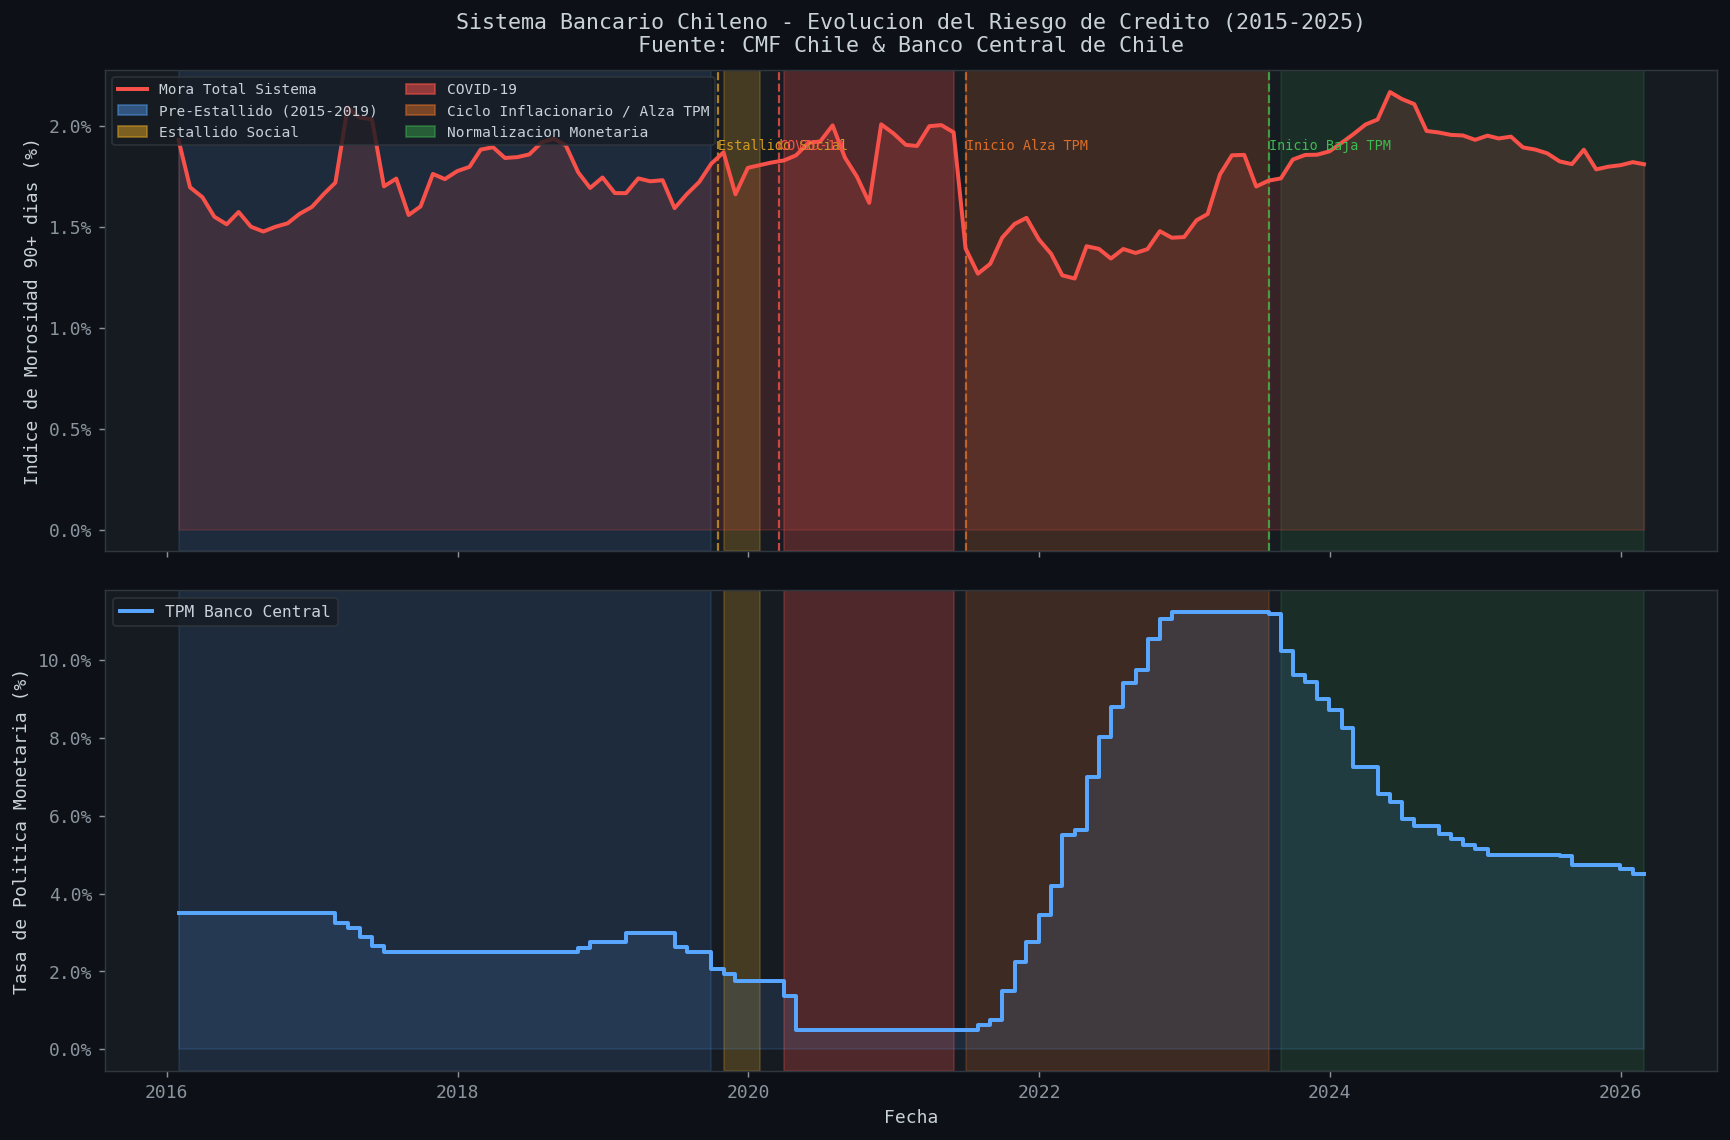

In [11]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 1, hspace=0.08)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# Panel superior: Morosidad del sistema
sombrear_ciclos(ax1, df_sistema)
ax1.plot(df_sistema['fecha'], df_sistema['mora_total'],
         color=ROJO, lw=2.2, label='Mora Total Sistema', zorder=3)
ax1.fill_between(df_sistema['fecha'], df_sistema['mora_total'],
                 alpha=0.15, color=ROJO)
ax1.set_ylabel('Indice de Morosidad 90+ dias (%)', fontsize=10)
ax1.set_title(
    'Sistema Bancario Chileno - Evolucion del Riesgo de Credito (2015-2025)\n'
    'Fuente: CMF Chile & Banco Central de Chile',
    fontsize=12, pad=10
)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.setp(ax1.get_xticklabels(), visible=False)

eventos = [
    ('2019-10-18', 'Estallido Social', AMARILLO),
    ('2020-03-18', 'COVID-19',         ROJO),
    ('2021-07-01', 'Inicio Alza TPM',  NARANJA),
    ('2023-08-01', 'Inicio Baja TPM',  VERDE),
]
for fecha_ev, texto, color in eventos:
    ax1.axvline(pd.Timestamp(fecha_ev), color=color, lw=1.2, ls='--', alpha=0.8)
    ax1.text(pd.Timestamp(fecha_ev), ax1.get_ylim()[1] * 0.85,
             texto, color=color, fontsize=7.5, ha='left', va='top')

# Panel inferior: TPM
sombrear_ciclos(ax2, df_sistema)
ax2.step(df_sistema['fecha'], df_sistema['tpm'],
         color=AZUL, lw=2.2, where='post', label='TPM Banco Central', zorder=3)
ax2.fill_between(df_sistema['fecha'], df_sistema['tpm'],
                 alpha=0.12, color=AZUL, step='post')
ax2.set_ylabel('Tasa de Politica Monetaria (%)', fontsize=10)
ax2.set_xlabel('Fecha', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax2.legend(loc='upper left', fontsize=9)

parches = [mpatches.Patch(color=c, alpha=a+0.3, label=k)
           for k, (c, a) in CICLO_COLORES.items()]
ax1.legend(handles=[ax1.lines[0]] + parches, loc='upper left', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(REPORT_DIR / '01_evolucion_historica.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Analisis por Tipo de Cartera

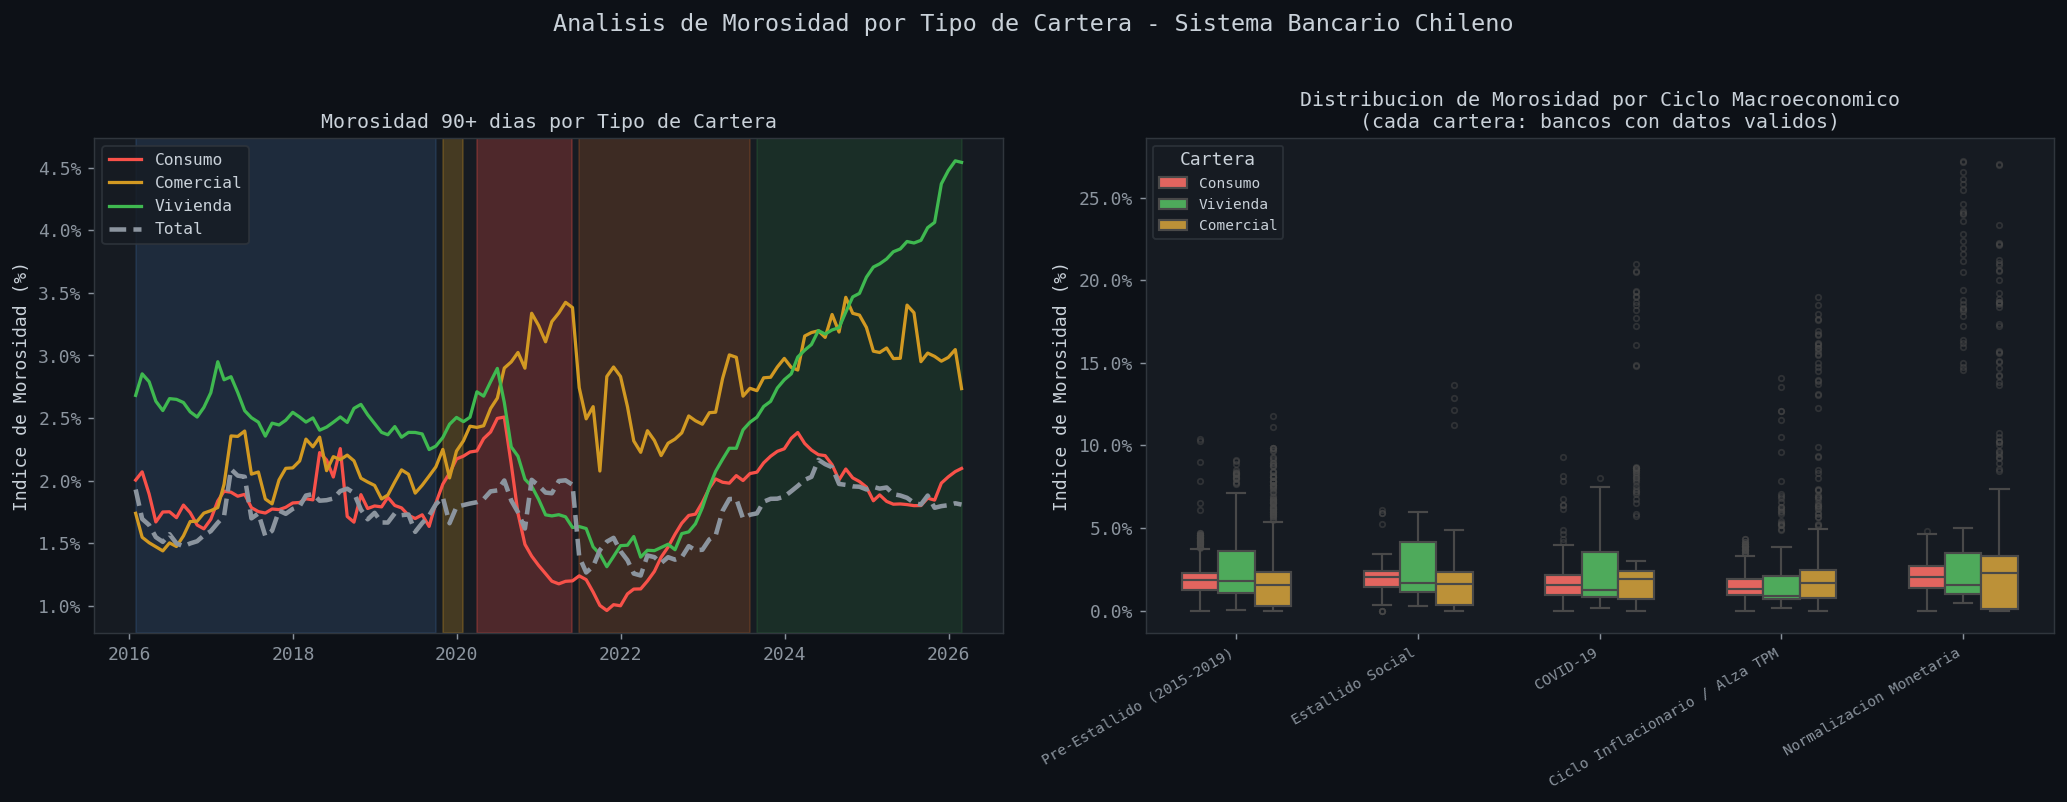

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sombrear_ciclos(ax, df_sistema)
carteras = [
    ('mora_consumo',   'Consumo',   ROJO),
    ('mora_comercial', 'Comercial', AMARILLO),
    ('mora_vivienda',  'Vivienda',  VERDE),
    ('mora_total',     'Total',     TEXT_MUT),
]
for col, label, color in carteras:
    lw = 2.5 if label == 'Total' else 1.8
    ls = '--' if label == 'Total' else '-'
    ax.plot(df_sistema['fecha'], df_sistema[col],
            color=color, lw=lw, ls=ls, label=label)
ax.set_title('Morosidad 90+ dias por Tipo de Cartera', fontsize=11)
ax.set_ylabel('Indice de Morosidad (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(fontsize=9)

ax = axes[1]
df_cons = df[df['tiene_cartera_consumo']][['ciclo','mora_consumo']].copy()
df_cons['cartera'] = 'Consumo'
df_cons = df_cons.rename(columns={'mora_consumo': 'mora'})

df_viv = df[df['tiene_cartera_vivienda']][['ciclo','mora_vivienda']].copy()
df_viv['cartera'] = 'Vivienda'
df_viv = df_viv.rename(columns={'mora_vivienda': 'mora'})

df_com = df[['ciclo','mora_comercial']].copy()
df_com['cartera'] = 'Comercial'
df_com = df_com.rename(columns={'mora_comercial': 'mora'})

df_box = pd.concat([df_cons, df_viv, df_com], ignore_index=True)
colores_box = {'Consumo': ROJO, 'Comercial': AMARILLO, 'Vivienda': VERDE}
orden_ciclos = [
    'Pre-Estallido (2015-2019)', 'Estallido Social',
    'COVID-19', 'Ciclo Inflacionario / Alza TPM', 'Normalizacion Monetaria'
]
sns.boxplot(
    data=df_box, x='ciclo', y='mora', hue='cartera',
    order=[c for c in orden_ciclos if c in df_box['ciclo'].unique()],
    palette=colores_box, ax=ax, width=0.6, linewidth=1.2,
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.5}
)
ax.set_title('Distribucion de Morosidad por Ciclo Macroeconomico\n(cada cartera: bancos con datos validos)', fontsize=11)
ax.set_ylabel('Indice de Morosidad (%)')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(title='Cartera', fontsize=8)

plt.suptitle('Analisis de Morosidad por Tipo de Cartera - Sistema Bancario Chileno',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR / '02_analisis_cartera.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Correlacion TPM con Morosidad — Analisis de Rezagos

En politica monetaria, los efectos de la TPM sobre el credito no son instantaneos.  
Operan con rezagos de 6 a 18 meses. Este analisis cuantifica ese mecanismo de transmision.

Rezago optimo: 17 meses | r = 0.6694


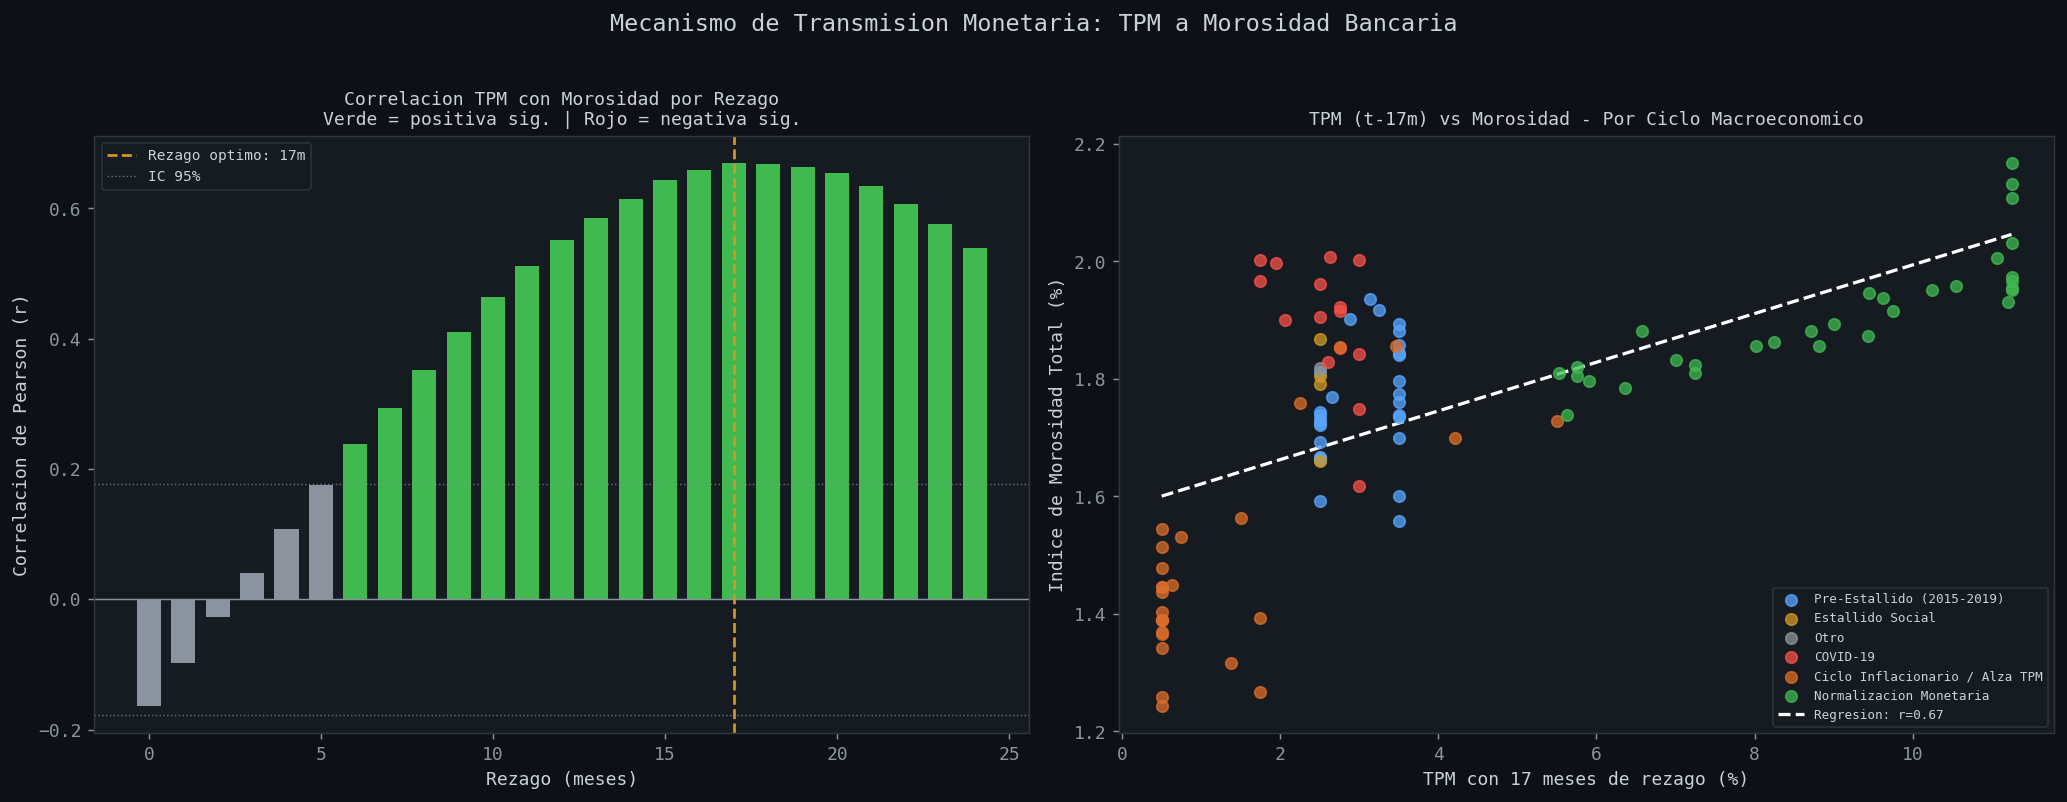

In [13]:
max_lag = 24
resultados_lag = []

for lag in range(0, max_lag + 1):
    df_lag = df_sistema.copy()
    df_lag['tpm_lag'] = df_lag['tpm'].shift(lag)
    df_lag = df_lag.dropna(subset=['tpm_lag', 'mora_total'])
    r_pearson,  p_pearson  = pearsonr(df_lag['tpm_lag'],  df_lag['mora_total'])
    r_spearman, p_spearman = spearmanr(df_lag['tpm_lag'], df_lag['mora_total'])
    resultados_lag.append({
        'lag'        : lag,
        'pearson_r'  : r_pearson,
        'spearman_r' : r_spearman,
        'p_pearson'  : p_pearson,
        'sig_95'     : p_pearson < 0.05,
    })

df_lag_res = pd.DataFrame(resultados_lag)
lag_optimo = df_lag_res.loc[df_lag_res['pearson_r'].abs().idxmax(), 'lag']
r_optimo   = df_lag_res.loc[df_lag_res['pearson_r'].abs().idxmax(), 'pearson_r']
print(f'Rezago optimo: {lag_optimo} meses | r = {r_optimo:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
colores_bar = [
    VERDE if (v > 0 and s) else ROJO if (v < 0 and s) else TEXT_MUT
    for v, s in zip(df_lag_res['pearson_r'], df_lag_res['sig_95'])
]
ax.bar(df_lag_res['lag'], df_lag_res['pearson_r'], color=colores_bar, width=0.7, edgecolor='none')
ax.axhline(0, color=TEXT_MUT, lw=0.8)
ax.axvline(lag_optimo, color=AMARILLO, lw=1.5, ls='--', label=f'Rezago optimo: {lag_optimo}m')
n    = len(df_sistema)
ci95 = 1.96 / np.sqrt(n)
ax.axhline( ci95, color=TEXT_MUT, lw=0.8, ls=':', alpha=0.7, label='IC 95%')
ax.axhline(-ci95, color=TEXT_MUT, lw=0.8, ls=':', alpha=0.7)
ax.set_xlabel('Rezago (meses)')
ax.set_ylabel('Correlacion de Pearson (r)')
ax.set_title('Correlacion TPM con Morosidad por Rezago\nVerde = positiva sig. | Rojo = negativa sig.', fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]
df_scatter = df_sistema.copy()
df_scatter['tpm_lag_opt'] = df_scatter['tpm'].shift(int(lag_optimo))
df_scatter = df_scatter.dropna(subset=['tpm_lag_opt', 'mora_total'])
cmap_ciclos = {c: col for c, (col, _) in CICLO_COLORES.items()}
for ciclo in df_scatter['ciclo'].unique():
    mask  = df_scatter['ciclo'] == ciclo
    color = cmap_ciclos.get(ciclo, TEXT_MUT)
    ax.scatter(df_scatter.loc[mask, 'tpm_lag_opt'],
               df_scatter.loc[mask, 'mora_total'],
               color=color, alpha=0.75, s=40, label=ciclo, zorder=3)
x = df_scatter['tpm_lag_opt']
y = df_scatter['mora_total']
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, m * x_line + b, color='white', lw=1.8, ls='--',
        label=f'Regresion: r={r_optimo:.2f}')
ax.set_xlabel(f'TPM con {lag_optimo} meses de rezago (%)')
ax.set_ylabel('Indice de Morosidad Total (%)')
ax.set_title(f'TPM (t-{lag_optimo}m) vs Morosidad - Por Ciclo Macroeconomico', fontsize=10)
ax.legend(fontsize=7)

plt.suptitle('Mecanismo de Transmision Monetaria: TPM a Morosidad Bancaria',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR / '03_tpm_morosidad_rezago.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Concentracion Bancaria — Indice HHI

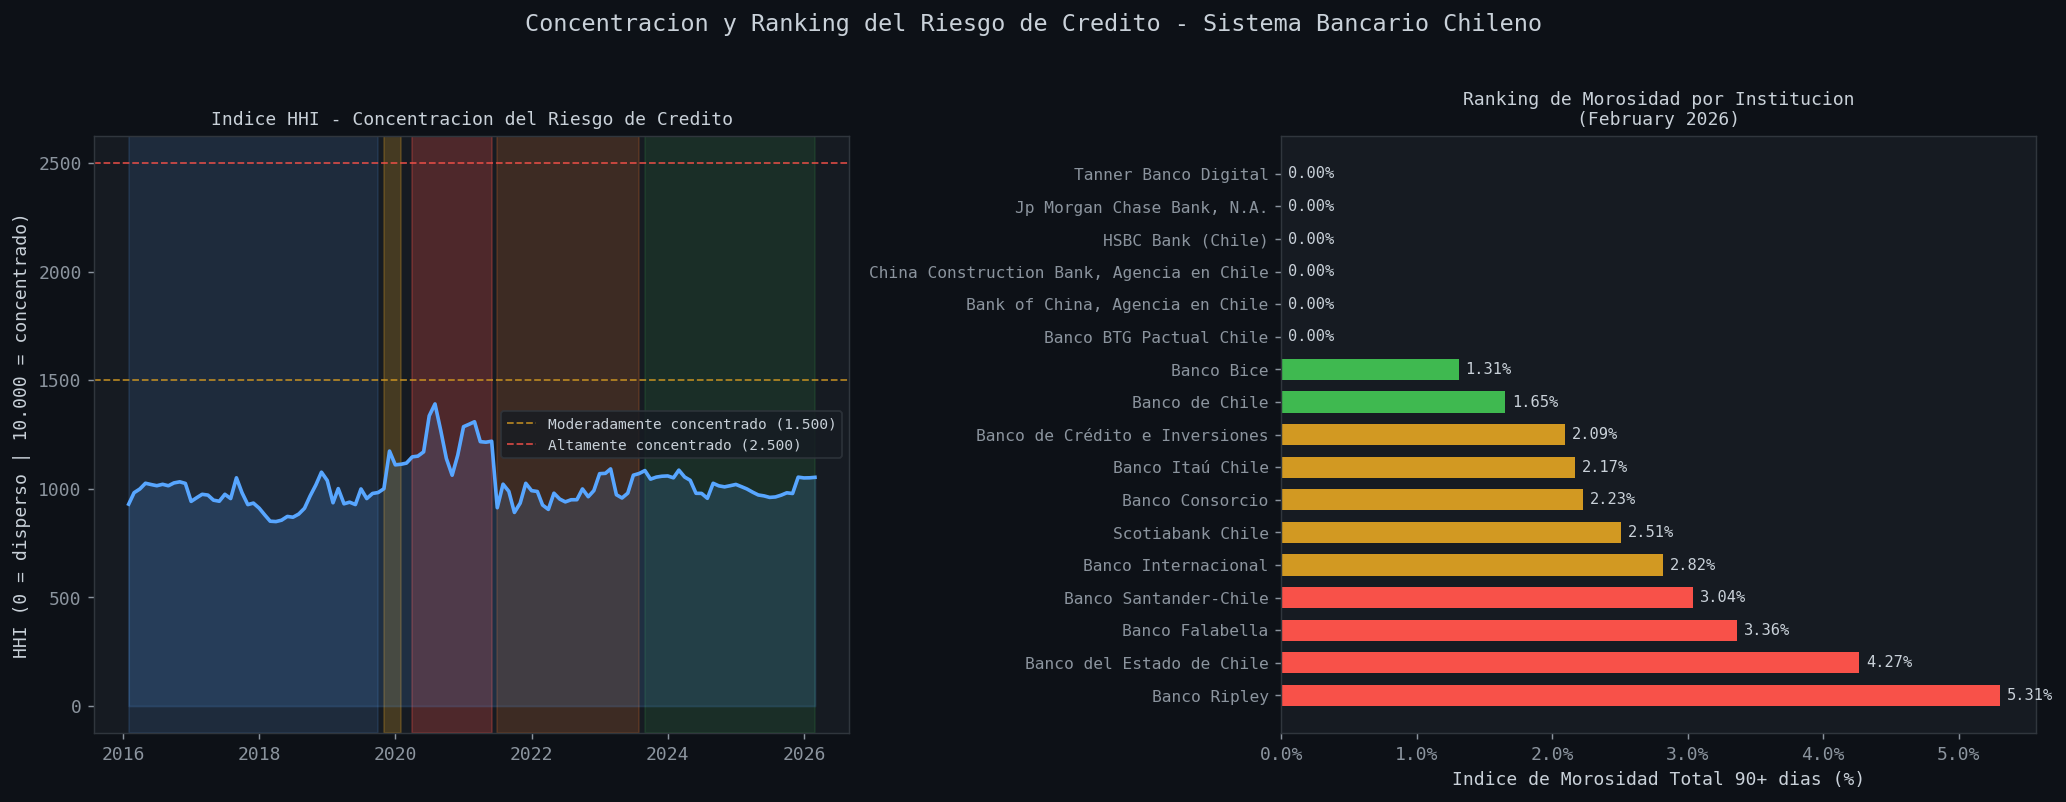

In [14]:
def calcular_hhi(serie):
    total = serie.sum()
    if total == 0:
        return 0
    cuotas = serie / total
    return (cuotas ** 2).sum() * 10_000

hhi_mensual = df.groupby('fecha').apply(
    lambda g: calcular_hhi(g['mora_total'])
).reset_index()
hhi_mensual.columns = ['fecha', 'hhi']
hhi_mensual = hhi_mensual.merge(df[['fecha','ciclo']].drop_duplicates(), on='fecha')

ultimo_mes = df['fecha'].max()
df_ranking = (
    df[df['fecha'] == ultimo_mes]
    .groupby('banco')[['mora_total','mora_consumo','mora_comercial','mora_vivienda']]
    .mean()
    .sort_values('mora_total', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sombrear_ciclos(ax, hhi_mensual)
ax.plot(hhi_mensual['fecha'], hhi_mensual['hhi'], color=AZUL, lw=2)
ax.fill_between(hhi_mensual['fecha'], hhi_mensual['hhi'], alpha=0.15, color=AZUL)
ax.axhline(1500, color=AMARILLO, lw=1, ls='--', alpha=0.8, label='Moderadamente concentrado (1.500)')
ax.axhline(2500, color=ROJO,     lw=1, ls='--', alpha=0.8, label='Altamente concentrado (2.500)')
ax.set_title('Indice HHI - Concentracion del Riesgo de Credito', fontsize=10)
ax.set_ylabel('HHI (0 = disperso | 10.000 = concentrado)')
ax.legend(fontsize=8)

ax = axes[1]
colores_rank = [ROJO if v > 3 else AMARILLO if v > 2 else VERDE
                for v in df_ranking['mora_total']]
bars = ax.barh(range(len(df_ranking)), df_ranking['mora_total'],
               color=colores_rank, height=0.65, edgecolor='none')
ax.set_yticks(range(len(df_ranking)))
ax.set_yticklabels(df_ranking['banco'], fontsize=9)
ax.set_xlabel('Indice de Morosidad Total 90+ dias (%)')
ax.set_title(f'Ranking de Morosidad por Institucion\n({ultimo_mes.strftime("%B %Y")})', fontsize=10)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
for bar, val in zip(bars, df_ranking['mora_total']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=8.5)

plt.suptitle('Concentracion y Ranking del Riesgo de Credito - Sistema Bancario Chileno',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR / '04_concentracion_hhi_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Analisis de Periodos de Estres

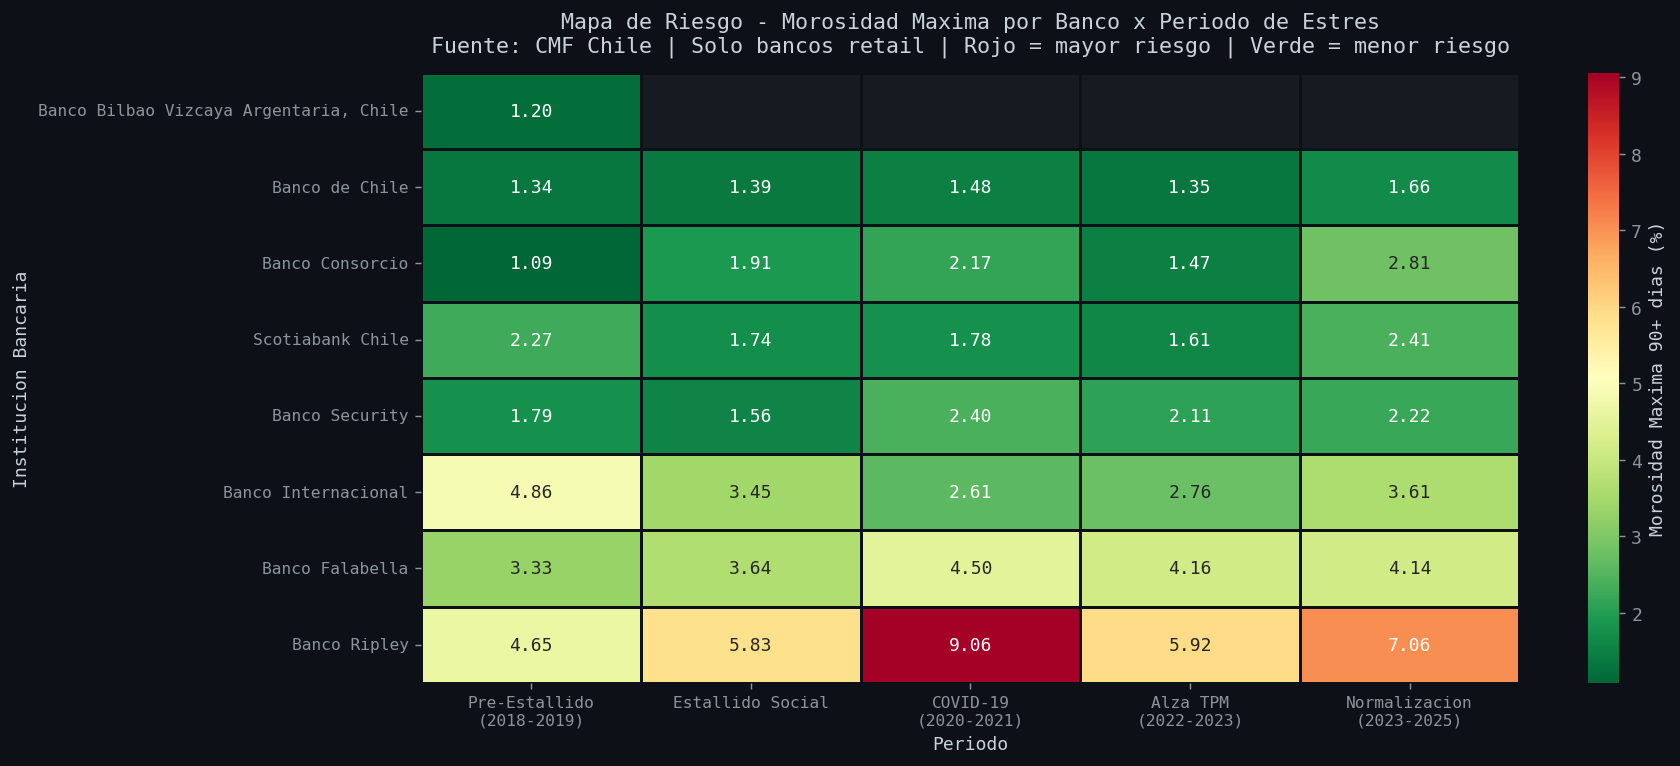

In [17]:
# Filtrar solo bancos retail para el heatmap de estres
bancos_retail = df[df['tipo_banco'] == 'Retail']['banco'].unique()

# Orden cronologico de los periodos (de mas antiguo a mas reciente)
ORDEN_PERIODOS = [
    'Pre-Estallido\n(2018-2019)',
    'Estallido Social',
    'COVID-19\n(2020-2021)',
    'Alza TPM\n(2022-2023)',
    'Normalizacion\n(2023-2025)',
]

periodos_estres = {
    'Pre-Estallido\n(2018-2019)' : ('2018-01-01', '2019-09-30'),
    'Estallido Social'           : ('2019-10-01', '2019-12-31'),
    'COVID-19\n(2020-2021)'      : ('2020-03-01', '2021-05-31'),
    'Alza TPM\n(2022-2023)'      : ('2022-01-01', '2023-07-31'),
    'Normalizacion\n(2023-2025)' : ('2023-08-01', '2025-12-31'),
}

registros_estres = []
for periodo, (ini, fin) in periodos_estres.items():
    mask    = df['fecha'].between(ini, fin) & df['banco'].isin(bancos_retail)
    resumen = df[mask].groupby('banco')['mora_total'].agg(['mean','max','std']).reset_index()
    resumen.columns = ['banco', 'mora_media', 'mora_max', 'mora_std']
    resumen['periodo'] = periodo
    registros_estres.append(resumen)

df_estres = pd.concat(registros_estres, ignore_index=True)

# Pivot con columnas en orden cronologico
pivot_max = df_estres.pivot(index='banco', columns='periodo', values='mora_max')
pivot_max = pivot_max.reindex(columns=ORDEN_PERIODOS)

# Ordenar filas por mora promedio total (de menor a mayor riesgo)
pivot_max = pivot_max.loc[pivot_max.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot_max,
    annot=True, fmt='.2f',
    cmap='RdYlGn_r',
    linewidths=0.8, linecolor=BG_DARK,
    cbar_kws={'label': 'Morosidad Maxima 90+ dias (%)'},
    ax=ax
)
ax.set_title(
    'Mapa de Riesgo - Morosidad Maxima por Banco x Periodo de Estres\n'
    'Fuente: CMF Chile | Solo bancos retail | Rojo = mayor riesgo | Verde = menor riesgo',
    fontsize=12, pad=12
)
ax.set_xlabel('Periodo')
ax.set_ylabel('Institucion Bancaria')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(REPORT_DIR / '05_heatmap_estres.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. Reporte Estadistico Final

In [18]:
mora_sistema_actual  = df_sistema['mora_total'].iloc[-1]
mora_max_historica   = df_sistema['mora_total'].max()
tpm_actual           = df_sistema['tpm'].iloc[-1]
banco_mas_riesgoso   = df_ranking['banco'].iloc[0]
banco_menos_riesgoso = df_ranking['banco'].iloc[-1]

print('=' * 65)
print('     REPORTE ESTADISTICO - SISTEMA BANCARIO CHILENO')
print('=' * 65)
print(f'  Periodo analizado    : Ene 2015 a {df["fecha"].max().strftime("%b %Y")}')
print(f'  Instituciones        : {df["banco"].nunique()} bancos')
print('-' * 65)
print(f'  SITUACION ACTUAL')
print(f'  Morosidad sistema    : {mora_sistema_actual:.2f}%')
print(f'  TPM vigente          : {tpm_actual:.2f}%')
print(f'  Banco mas riesgoso   : {banco_mas_riesgoso} ({df_ranking["mora_total"].iloc[0]:.2f}%)')
print(f'  Banco mas solido     : {banco_menos_riesgoso} ({df_ranking["mora_total"].iloc[-1]:.2f}%)')
print('-' * 65)
print(f'  HALLAZGOS CLAVE')
print(f'  Mora max historica   : {mora_max_historica:.2f}% (durante COVID-19)')
print(f'  Rezago TPM a mora    : {lag_optimo} meses (r = {r_optimo:.3f})')
print(f'  Cartera mas riesgosa : Consumo (mora prom {df_sistema["mora_consumo"].mean():.2f}%)')
print(f'  Cartera mas solida   : Vivienda (mora prom {df_sistema["mora_vivienda"].mean():.2f}%)')
print('=' * 65)

     REPORTE ESTADISTICO - SISTEMA BANCARIO CHILENO
  Periodo analizado    : Ene 2015 a Feb 2026
  Instituciones        : 25 bancos
-----------------------------------------------------------------
  SITUACION ACTUAL
  Morosidad sistema    : 1.81%
  TPM vigente          : 4.50%
  Banco mas riesgoso   : Banco Ripley (5.31%)
  Banco mas solido     : Tanner Banco Digital (0.00%)
-----------------------------------------------------------------
  HALLAZGOS CLAVE
  Mora max historica   : 2.17% (durante COVID-19)
  Rezago TPM a mora    : 17 meses (r = 0.669)
  Cartera mas riesgosa : Consumo (mora prom 1.81%)
  Cartera mas solida   : Vivienda (mora prom 2.55%)
